# Lesson 2.8 — 草稿 notebook：环境、trajectory 与 expert planner

这是一个**工作用 notebook**，而不是整理过的课程。它保留了项目找出如何产出一个成功的 PickCube demonstration 的完整路径，包括走过的弯路。这里的一切都是分三轮写成的：

1. **环境基础**（2.8.1–2.8.2）—— 构建 `PickCube-v1`，读取 42 维 observation，采样并 step 一个 action。
2. **随机 trajectory 采集** —— 组装一个 transition 列表和一个完整 episode。
3. **寻找 planner** —— 在已安装的 ManiSkill 包中搜索 demonstration 生成器，转向 `pd_joint_pos`，并构建 planner。

> **关于顺序的说明。** 原文件末尾的三处 import 自检（`mplib`、`sapien`、planner 类）已被**上移**，放到它们所支撑的 planner 构建之前。它们的代码未变，记录的 outputs 也是原始结果，因此 `execution_count` 的取值现在看起来是乱序的。除此之外，cell 的 source 与 outputs 未作其他修改。

## 为什么 `pd_joint_pos` 会出现在中间

第一轮使用的是 `pd_joint_delta_pos`，也就是项目 dataset fixture 的控制模式。planner 后来拒绝了它：它的 gripper 辅助函数输出 `[qpos(7), gripper]`，即一个 8 维的 **absolute** 位置 action，因此 delta 模式的环境会失败并报 `Received action of shape torch.Size([15]) but expected shape (1, 8)`。后半部分切换到 `pd_joint_pos`，正是对这一发现过程的记录。

> **环境要求。** 构建 planner 需要 `mplib`，而它是针对 NumPy 1.x 的 C API 编译的。在 NumPy 2.x 的环境中，本 notebook 的 planner cell 会以 `SIGSEGV`（地址 `0x0`）终止 kernel。请在 `embodied310`（NumPy 1.26.4）下运行 planner 相关的 cells；参见 `notes/progress.md`。

成功路径的整理版本位于 `2.9_expert_demonstrations.ipynb`；批量采集器是 `scripts/generate_expert_demo.py`。

## 2.8.1 — 构建环境

三个参数决定了 agent 看到什么、做什么：

- `obs_mode="state"` —— 展平的 robot + object state vector，不含图像。
- `control_mode="pd_joint_delta_pos"` —— action 是**关节位置的变化量**，也就是项目 dataset fixture 使用的模式。
- `render_mode="rgb_array"` —— 在 notebook 中无需 display server 即可工作。

In [1]:
import gymnasium as gym

import mani_skill.envs


# --------------------------------------------------
# Create PickCube environment
#
# obs_mode:
#   state = robot + object information
#
# control_mode:
#   pd_joint_delta_pos
#   means action controls joint position change
#
# render_mode:
#   rgb_array works better in notebook
# --------------------------------------------------

env = gym.make(
    "PickCube-v1",
    obs_mode="state",
    control_mode="pd_joint_delta_pos",
    render_mode="rgb_array",
)


print("Environment initialized")

print("Observation:")
print(env.observation_space)

print("Action:")
print(env.action_space)

/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment initialized
Observation:
Box(-inf, inf, (1, 42), float32)
Action:
Box(-1.0, 1.0, (8,), float32)


In [2]:
# --------------------------------------------------
# Reset simulator
#
# This creates:
# - physics scene
# - robot
# - objects
# - task state
# --------------------------------------------------

obs, info = env.reset()


print("Reset successful!")

print("Observation shape:")
print(obs.shape)

Reset successful!
Observation shape:
torch.Size([1, 42])


### Reset 并读取 42 维 observation

`env.reset()` 构建物理场景、robot、objects 以及 task state。返回的 tensor 形状为 `(num_envs, 42)`：首轴之所以存在，是因为 ManiSkill 是向量化的，而这里 `num_envs=1`。

`obs_mode="state"` 只返回一个扁平 vector，因此这 42 个数字背后的结构必须手工逐层剥开。已验证的布局为

```text
[0:9]   qpos
[9:18]  qvel
[18:19] is_grasped
[19:26] tcp_pose
[26:29] goal_pos
[29:36] obj_pose
[36:39] tcp_to_obj_pos
[39:42] obj_to_goal_pos
```

In [3]:
# Print the raw observation tensor
#
# obs shape:
# (num_envs, state_dimension)
#
# Here:
# num_envs = 1
# state_dimension = 42


print(obs)

print("-------------------")

print("dtype:")
print(obs.dtype)

print("-------------------")

print("device:")
print(obs.device)

tensor([[ 7.5563e-03,  3.9089e-01, -4.6119e-02, -1.9406e+00, -3.0713e-02,
          2.3389e+00,  8.0573e-01,  4.0000e-02,  4.0000e-02,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  5.7635e-03,
         -2.7263e-02,  1.7933e-01,  1.9895e-02,  9.9965e-01, -1.7043e-02,
          3.6389e-03, -6.0588e-02,  4.8892e-02,  6.7875e-02,  6.9783e-02,
         -2.6644e-02,  2.0000e-02,  4.1636e-01, -0.0000e+00, -0.0000e+00,
         -9.0920e-01,  6.4019e-02,  6.1985e-04, -1.5933e-01, -1.3037e-01,
          7.5535e-02,  4.7875e-02]])
-------------------
dtype:
torch.float32
-------------------
device:
cpu


In [4]:
# Convert torch tensor to numpy array
#
# detach:
# remove gradient tracking
#
# cpu:
# move data from GPU to CPU
#
# numpy:
# convert to numpy format


state = (
    obs
    .detach()
    .cpu()
    .numpy()
)


print(state.shape)

(1, 42)


In [5]:
def analyze_pickcube_state(state):
    """
    Analyze PickCube-v1 state observation.

    Current observation contains:
    - robot joint information
    - end-effector pose
    - object pose
    - goal information
    - gripper state

    This helps us understand:
    what information a robot policy receives.
    """

    # Remove environment dimension
    # shape:
    # (1,42) -> (42,)

    state = state[0]


    print("Total dimensions:")
    print(len(state))


    print("\n========== Robot Joint Position ==========")

    # First 9 dimensions:
    # robot joint position information

    print(state[:9])


    print("\n========== Robot Joint Velocity ==========")

    # Next 9 dimensions:
    # robot joint velocity

    print(state[9:18])


    print("\n========== End Effector Pose ==========")

    # Position + orientation

    print(state[18:25])


    print("\n========== Object Pose ==========")

    # Cube position and orientation

    print(state[25:32])


    print("\n========== Goal ==========")

    # Target position

    print(state[32:35])


    print("\n========== Relative Information ==========")

    # Relative distance information

    print(state[35:41])


    print("\n========== Gripper ==========")

    # Open / close state

    print(state[41])

In [6]:
analyze_pickcube_state(state)

Total dimensions:
42

========== Robot Joint Position ==========
[ 0.00755627  0.39089483 -0.04611887 -1.9406402  -0.03071309  2.3389194
  0.8057291   0.04        0.04      ]

========== Robot Joint Velocity ==========
[0. 0. 0. 0. 0. 0. 0. 0. 0.]

========== End Effector Pose ==========
[ 0.          0.0057635  -0.02726336  0.17932712  0.01989457  0.9996503
 -0.01704317]

========== Object Pose ==========
[ 0.00363891 -0.06058848  0.04889161  0.06787482  0.06978285 -0.02664351
  0.02      ]

========== Goal ==========
[ 0.41636404 -0.         -0.        ]

========== Relative Information ==========
[-9.0919799e-01  6.4019345e-02  6.1984546e-04 -1.5932712e-01
 -1.3037133e-01  7.5535126e-02]

========== Gripper ==========
0.04787482


## 2.8.2 — Action 与 step 循环

`env.action_space.sample()` 从 `[-1, 1]^8` 中均匀随机采样一个 action。这是一个 **pipeline fixture**，而不是 policy：由此得到的 trajectory 具备合法的结构，但基本上没有有用的行为。

`env.step(action)` 返回五个值。其中两个是彼此独立的停止条件，很容易混为一谈：

- `terminated` —— 任务以成功或不可恢复的失败结束；
- `truncated` —— episode 触及了 step 数或时间上限，这与是否成功无关。

In [7]:
# Sample one random action

action = env.action_space.sample()

print("Action:")
print(action)

print("----------------")

print("Shape:")
print(action.shape)

Action:
[ 0.98267037  0.00638925  0.1974071  -0.58535635 -0.08752356  0.24854542
 -0.80926013  0.57111895]
----------------
Shape:
(8,)


### 关于重复的采样 cell

上面的 cell 和下面的 cell 都调用了 `env.action_space.sample()`。前者是最小版本；后者重复了一次，并把 shape 检查明确写了出来。这一重复被作为原始记录保留 —— 两者内容完全相同。

In [8]:
# --------------------------------------------------
# Sample one action from ManiSkill action space
#
# Action represents:
# "what the robot should do at this timestep"
#
# Current control mode:
# pd_joint_delta_pos
#
# Therefore:
# action = desired joint position change
# --------------------------------------------------


action = env.action_space.sample()


print("Action:")
print(action)


print("------------------------")


print("Action shape:")
print(action.shape)

Action:
[ 0.12594582  0.76910776  0.78499085  0.98283994 -0.5172052  -0.4766328
  0.9037575  -0.9360165 ]
------------------------
Action shape:
(8,)


两个 cell 都从同一个 space 中采样一个 action，因此这里打印出的 shape 就是 action 的约定：位于 `[-1, 1]` 中的 `(8,)`，由向量化的 `Box(-1.0, 1.0, (8,), float32)` reshape 为 `(8,)`。

In [9]:
# --------------------------------------------------
# Execute one robot action
#
# env.step(action):
#
# input:
#     action_t
#
# output:
#     next observation
#     reward
#     termination signal
# --------------------------------------------------


next_obs, reward, terminated, truncated, info = env.step(action)


print("Next observation:")
print(next_obs.shape)


print("----------------")


print("Reward:")
print(reward)


print("----------------")


print("Info:")
print(info)

Next observation:
torch.Size([1, 42])
----------------
Reward:
tensor([0.0632])
----------------
Info:
{'elapsed_steps': tensor([1], dtype=torch.int32), 'success': tensor([False]), 'is_obj_placed': tensor([False]), 'is_robot_static': tensor([False]), 'is_grasped': tensor([False])}


## 2.8.3 — 采集一个随机 episode

下面两个代码块构建的是同一件事，只是细致程度不同：先是仅 20 步的 `(observation, action, reward)` 裸列表，然后是一个完整 episode，它还会记录 success 标志并在 `terminated` / `truncated` 时停止。

这个 list-of-dicts **就是**最小的 robot dataset 格式。下游的一切（HDF5、LeRobot、DataLoader）都只是围绕它的簿记工作。

存储的 observation 是施加 action **之前**的 state，这正是 `(o_t, a_t)` 配对约定的由来。

### 为什么同时检查 `terminated` 和 `truncated`

只依据 `terminated` 停止会越过时间上限；只依据 `truncated` 停止则会忽略提前到来的成功。循环在两者任一满足时退出，这才使记录到的长度有意义。

注意这个循环确立的配对约定：在第 `t` 步追加的 observation 是该步**进入时**的 state，因此存储的列表是 `(o_t, a_t)` —— 而不是 `(o_t, a_{t+1})`。

### 最小 transition 列表

最小可用的容器：三个并列的列表。它只记录循环所消耗和产生的全部内容，别无其他 —— 没有 success 标志，也没有停止条件。

In [10]:
# --------------------------------------------------
# Collect one short trajectory
#
# We store:
# observation
# action
# reward
#
# This is the minimal robot dataset format
# --------------------------------------------------


trajectory = {
    "observations": [],
    "actions": [],
    "rewards": []
}


# Reset environment

obs, info = env.reset()


for step in range(20):

    # Random action for now
    # Later replaced by expert action

    action = env.action_space.sample()


    next_obs, reward, terminated, truncated, info = env.step(action)


    # Store current transition

    trajectory["observations"].append(
        obs.cpu().numpy()
    )


    trajectory["actions"].append(
        action
    )


    trajectory["rewards"].append(
        reward
    )


    obs = next_obs


    if terminated or truncated:
        break



print(
    "Collected steps:",
    len(trajectory["actions"])
)

Collected steps: 20


### 如实解读结果

这里得到的是一个**随机** episode：总 reward 很小，本 notebook 中没有任何 episode 成功。这是预期之内的，也正是重点所在 —— 这条 trajectory 用来验证 pipeline，它无法训练 policy。

区分随机数据与 expert 数据的信号是 action 的平滑度，而不是 reward：随机 action 在相邻 step 之间的跳变为 `mean |Δa| ≈ 0.67`，而 expert planner 的 action 为 `≈ 0.0078`。参见 `2.9_expert_demonstrations.ipynb`。

In [11]:
print(trajectory["rewards"])
print("Total reward:",
      sum(trajectory["rewards"]))

[tensor([0.0531]), tensor([0.0580]), tensor([0.0527]), tensor([0.0523]), tensor([0.0512]), tensor([0.0552]), tensor([0.0486]), tensor([0.0430]), tensor([0.0468]), tensor([0.0470]), tensor([0.0357]), tensor([0.0303]), tensor([0.0281]), tensor([0.0288]), tensor([0.0341]), tensor([0.0349]), tensor([0.0290]), tensor([0.0273]), tensor([0.0266]), tensor([0.0285])]
Total reward: tensor([0.8111])


### 带停止条件的完整 episode

思路相同，但它还会存储 `success`，并在 `terminated` / `truncated` 时停止，因此返回的长度反映的是真实的 episode 边界，而不是固定的 step 预算。

In [12]:
# --------------------------------------------------
# Collect one complete episode
#
# We record:
# - observation
# - action
# - reward
# - success
#
# This format is closer to real robot datasets
# --------------------------------------------------


def collect_random_episode(env, max_steps=200):

    trajectory = {
        "observations": [],
        "actions": [],
        "rewards": [],
        "success": False,
    }


    obs, info = env.reset()


    for step in range(max_steps):

        # Random policy
        action = env.action_space.sample()


        next_obs, reward, terminated, truncated, info = env.step(action)


        # Save transition

        trajectory["observations"].append(
            obs.cpu().numpy()
        )

        trajectory["actions"].append(
            action
        )

        trajectory["rewards"].append(
            reward.cpu().numpy()
        )


        obs = next_obs


        if terminated or truncated:

            trajectory["success"] = (
                info["success"].item()
            )

            break


    return trajectory

In [13]:
random_traj = collect_random_episode(env)

print(
    "Length:",
    len(random_traj["actions"])
)

print(
    "Success:",
    random_traj["success"]
)

Length: 50
Success: False


## 2.8.4 — 寻找 demonstration 生成器

ManiSkill 3 改变了它的 API，因此定位 planner 的方式是检查**已安装的包**，而不是相信较旧的教程。下面的搜索遍历 `mani_skill` 目录树，查找 demonstration 文件、agents、motion-planning 模块，最后是 `PickCube` 实现本身。

直接阅读 `motionplanner.py` 才是关键：它是生成 demonstration trajectory 的 expert controller，因此它的接口定义了成功的 episode 应当是什么样子。

In [14]:
import os
import mani_skill


# --------------------------------------------------
# Get ManiSkill installation directory
#
# We need this path to inspect:
# - demos
# - examples
# - utilities
# --------------------------------------------------

mani_skill_path = os.path.dirname(
    mani_skill.__file__
)


print("ManiSkill path:")
print(mani_skill_path)

ManiSkill path:
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill


上面的 cell 从导入的 module 计算出 `mani_skill_path`，因此这次搜索会跟随已安装包的实际所在位置。这是定位 ManiSkill 内部实现的通用做法 —— 不同于下面两格中硬编码的路径。

In [15]:
# --------------------------------------------------
# Search files related to demonstrations
#
# ManiSkill version 3 changed some APIs,
# so we inspect the installed package
# instead of assuming old tutorials.
# --------------------------------------------------

for root, dirs, files in os.walk(mani_skill_path):

    for file in files:

        if "demo" in file.lower():

            print(
                os.path.join(root, file)
            )

/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_vis_textures.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_vis_pcd.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_robot.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_random_action.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_reset_distribution.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_manual_control_continuous.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_vis_segmentation.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/demo_manual_control.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/m

In [16]:
# --------------------------------------------------
# Search robot agents
#
# ManiSkill uses agents to represent:
# - robot model
# - controller
# - action interface
# --------------------------------------------------

for root, dirs, files in os.walk(mani_skill_path):

    for file in files:

        if "agent" in file.lower():

            print(
                os.path.join(root, file)
            )

/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/base_agent.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/base_real_agent.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/multi_agent.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/__pycache__/multi_agent.cpython-310.pyc
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/__pycache__/base_agent.cpython-310.pyc
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/agents/__pycache__/base_real_agent.cpython-310.pyc


In [17]:
# --------------------------------------------------
# Search motion planning related modules
#
# Expert demonstrations in simulation are usually
# generated by planners.
# --------------------------------------------------

keywords = [
    "motion",
    "planner",
    "planning"
]


for root, dirs, files in os.walk(mani_skill_path):

    for file in files:

        filename = file.lower()

        for keyword in keywords:

            if keyword in filename:

                print(
                    os.path.join(root, file)
                )

                break

/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/xarm6/motionplanner.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/xarm6/__pycache__/motionplanner.cpython-310.pyc
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/two_finger_gripper/motionplanner.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/two_finger_gripper/__pycache__/motionplanner.cpython-310.pyc
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/panda/motionplanner.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/panda/motionplanner_stick.py
/home/bowenyuan/miniforge3/envs/embodied310/lib/python3.10/site-packages/mani_skill/examples/motionplanning/panda/__pycache__/motion

In [18]:
# --------------------------------------------------
# Find PickCube implementation
# --------------------------------------------------

for root, dirs, files in os.walk(mani_skill_path):

    for file in files:

        if "pickcube" in file.lower():

            print(
                os.path.join(root, file)
            )

### 陷阱：这些路径是绝对的，且与环境相关

下面两处检查都通过一个**硬编码的绝对路径**打开文件，该路径嵌入了 `embodied` 环境的 Python 版本：

```text
/home/bowenyuan/miniforge3/envs/embodied/lib/python3.12/site-packages/...
```

这在本机上可行，但在任何其他 Python 版本、环境名或安装位置上都会失效。这也是下面那个 cell 中第二条路径带有第二个硬编码前缀的原因。更好的做法是从 module 推导路径，正如上面的搜索 cells 已经做的那样：

```python
path = Path(mani_skill.__file__).parent / "examples" / "motionplanning" / "..."
```

In [19]:
# --------------------------------------------------
# Inspect Panda motion planner
#
# This is the expert controller used for generating
# demonstration trajectories.
# --------------------------------------------------

planner_path = (
    "/home/bowenyuan/miniforge3/envs/embodied/lib/python3.12/site-packages/"
    "mani_skill/examples/motionplanning/panda/motionplanner.py"
)


with open(planner_path, "r") as f:
    planner_code = f.read()


print(planner_code[:4000])

import mplib
import numpy as np
import sapien

from mani_skill.envs.sapien_env import BaseEnv
from mani_skill.examples.motionplanning.two_finger_gripper.motionplanner import TwoFingerGripperMotionPlanningSolver


class PandaArmMotionPlanningSolver(TwoFingerGripperMotionPlanningSolver):
    OPEN = 1
    CLOSED = -1
    MOVE_GROUP = "panda_hand_tcp"

    def __init__(
        self,
        env: BaseEnv,
        debug: bool = False,
        vis: bool = True,
        base_pose: sapien.Pose = None,  # TODO mplib doesn't support robot base being anywhere but 0
        visualize_target_grasp_pose: bool = True,
        print_env_info: bool = True,
        joint_vel_limits=0.9,
        joint_acc_limits=0.9,
    ):
        super().__init__(env, debug, vis, base_pose, visualize_target_grasp_pose, print_env_info, joint_vel_limits, joint_acc_limits)


In [20]:
planner_path = "/home/bowenyuan/miniforge3/envs/embodied/lib/python3.12/site-packages/mani_skill/examples/motionplanning/two_finger_gripper/motionplanner.py"

with open(planner_path, "r") as f:
    code = f.read()

print(code[:8000])

import mplib
import numpy as np
import sapien

from mani_skill.envs.sapien_env import BaseEnv
from mani_skill.envs.scene import ManiSkillScene
from mani_skill.examples.motionplanning.base_motionplanner.motionplanner import BaseMotionPlanningSolver
from transforms3d import quaternions


class TwoFingerGripperMotionPlanningSolver(BaseMotionPlanningSolver):
    OPEN = 1
    CLOSED = -1

    def __init__(
        self,
        env: BaseEnv,
        debug: bool = False,
        vis: bool = True,
        base_pose: sapien.Pose = None,  # TODO mplib doesn't support robot base being anywhere but 0
        visualize_target_grasp_pose: bool = True,
        print_env_info: bool = True,
        joint_vel_limits=0.9,
        joint_acc_limits=0.9,
    ):
        super().__init__(env, debug, vis, base_pose, print_env_info, joint_vel_limits, joint_acc_limits)
        self.gripper_state = self.OPEN
        self.visualize_target_grasp_pose = visualize_target_grasp_pose
        self.grasp_pose_visual = N

## 2.8.5 — Motion planning 需要 `pd_joint_pos`

第一轮正是在这里撞上了这一约束。

`env.unwrapped` 去掉 Gymnasium wrapper 以触及 ManiSkill API —— agent、robot、它的 links 与 joints，以及 planner 所需的 base pose。在 delta 模式的环境上，planner 的 action 约定无法被满足。

下面 `pd_joint_pos` 环境被创建了两次（一次用于检查，一次用于 planning 运行）。这一重复被保留：它是原始可用的记录，而第二个代码块才是 planner 所绑定的那一个。

In [21]:
# ==========================================
# Step 0:
# Create ManiSkill environment
# ==========================================

import gymnasium as gym
import mani_skill.envs


env = gym.make(
    "PickCube-v1",
    obs_mode="state",
    control_mode="pd_joint_delta_pos",
    render_mode="rgb_array",
)


print("Environment created")
print(type(env))

Environment created
<class 'mani_skill.utils.registration.TimeLimitWrapper'>


In [22]:
# ==========================================
# Step 1:
# Remove Gymnasium wrapper
# ==========================================


real_env = env.unwrapped


print("Environment:")
print(type(real_env))


print("----------------")


print("Robot agent:")
print(type(real_env.agent))

Environment:
<class 'mani_skill.envs.tasks.tabletop.pick_cube.PickCubeEnv'>
----------------
Robot agent:
<class 'mani_skill.agents.robots.panda.panda.Panda'>


In [23]:
# ==========================================
# Step 2:
# Inspect Panda robot
# ==========================================


robot = real_env.agent.robot


print("Robot:")
print(robot)


print("----------------")


print("Robot attributes:")
print(
    [x for x in dir(robot) if "pose" in x.lower()]
)

Robot:
<panda: struct of type <class 'mani_skill.utils.structs.articulation.Articulation'>; managing 1 <class 'sapien.pysapien.physx.PhysxArticulation'> objects>
----------------
Robot attributes:
['get_pose', 'get_root_pose', 'initial_pose', 'pose', 'root_pose', 'set_pose', 'set_root_pose']


In [24]:
# ==========================================
# Step 3:
# Get robot base pose
# ==========================================


robot_base_pose = robot.pose


print(robot_base_pose)

Pose(raw_pose=tensor([[-6.1500e-01,  7.2760e-11, -1.4901e-08,  1.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00]]))


In [25]:
print(real_env.control_mode)

pd_joint_delta_pos


下面的注释 —— *"Motion planner outputs joint positions"* —— 正是这第二个环境存在的全部原因。也就是 2.8.1 中 `pd_joint_delta_pos` 的假设被打破的那一刻。

In [26]:
import gymnasium as gym
import mani_skill.envs


env = gym.make(
    "PickCube-v1",
    obs_mode="state",

    # Important:
    # Motion planner outputs joint positions.
    # This cell only inspects the mode; the planner is bound to the env created below.
    control_mode="pd_joint_pos",

    render_mode="rgb_array",
)


print(env)

<TimeLimitWrapper<OrderEnforcing<PickCubeEnv<PickCube-v1>>>>


In [27]:
real_env = env.unwrapped

print(real_env.control_mode)

pd_joint_pos


### 两个 `pd_joint_pos` 环境各自的作用

- 上面紧邻的 cell 用于**检查**模式（`print(real_env.control_mode)`）；
- 下面的 cell 才是 planner 实际**绑定**的那一个，其中的 `real_env` 被用于 `reset`、`robot_base_pose` 以及 planner 构造函数。

两者设置的选项完全相同，这一重复被作为原始记录保留。重新运行 notebook 时，请注意后面的 cells 闭包捕获的是哪一个 `env`。

In [28]:
# ==================================================
# Create PickCube environment for Motion Planning
#
# Important:
# Motion Planner outputs joint positions.
#
# Therefore:
# control_mode = pd_joint_pos
#
# ==================================================

import gymnasium as gym
import mani_skill.envs


env = gym.make(
    "PickCube-v1",

    # We first use state observation
    # because motion planner does not need images
    obs_mode="state",

    # Important:
    # Planner outputs joint position targets.
    # This is the environment the planner is bound to.
    control_mode="pd_joint_pos",

    render_mode="rgb_array",
)


print("Environment created")

print(type(env))

print("----------------")

print("Control mode:")
print(env.unwrapped.control_mode)

Environment created
<class 'mani_skill.utils.registration.TimeLimitWrapper'>
----------------
Control mode:
pd_joint_pos


In [29]:
# ==================================================
# Remove Gym wrapper
# ==================================================

real_env = env.unwrapped


print(type(real_env))

print(real_env.agent)

<class 'mani_skill.envs.tasks.tabletop.pick_cube.PickCubeEnv'>


In [30]:
# ==================================================
# Reset environment
#
# The planner needs:
# - current robot state
# - cube position
# - goal position
# ==================================================

obs, info = real_env.reset()


print("Observation:")
print(obs.shape)

print("----------------")

print(info)

Observation:
torch.Size([1, 42])
----------------
{'elapsed_steps': tensor([0], dtype=torch.int32), 'success': tensor([False]), 'is_obj_placed': tensor([False]), 'is_robot_static': tensor([True]), 'is_grasped': tensor([False]), 'reconfigure': False}


In [31]:
robot_base_pose = real_env.agent.robot.pose

print(robot_base_pose)

Pose(raw_pose=tensor([[-6.1500e-01,  7.2760e-11, -1.4901e-08,  1.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00]]))


## 2.8.6 — 构建 expert planner

在构造任何东西之前，先确认各组件能够 import。这三个 cell 原本位于原文件末尾；它们被移到这里，因为它们是前置条件，而不是结论。

`PandaArmMotionPlanningSolver` 就是 expert controller。它针对**解包后**（unwrapped）的环境构造，并传入 robot base pose，因为除非另有说明，`mplib` 会假定 base 位于原点。

> **这就是那个需要 NumPy 1.x 的 cell。** 在 NumPy 2.x 下运行它，会让 kernel 在 `mplib` 内部发生 segmentation fault 而终止，且无法被 `try` / `except` 捕获。在 `embodied310`（NumPy 1.26.4）下它可以成功构建。

In [32]:
import mplib
print("mplib ok")

mplib ok


In [33]:
import sapien
print("sapien ok")

sapien ok


In [34]:
from mani_skill.examples.motionplanning.panda.motionplanner import PandaArmMotionPlanningSolver
print("planner class ok")

planner class ok


In [35]:
# ==========================================
# Import Panda Motion Planner
#
# This class provides the expert planner
# for Panda robot.
# ==========================================

from mani_skill.examples.motionplanning.panda.motionplanner import (
    PandaArmMotionPlanningSolver
)


print("PandaArmMotionPlanningSolver imported!")

PandaArmMotionPlanningSolver imported!


In [36]:
import sys
import numpy as np

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("NumPy version    :", np.__version__)

assert "embodied310" in sys.executable, (
    "Motion planner must run in embodied310. "
    "Switch the notebook kernel or run the complete generation script "
    "through conda run -n embodied310."
)

Python executable: /home/bowenyuan/miniforge3/envs/embodied310/bin/python
Python version   : 3.10.21
NumPy version    : 1.26.4


In [37]:
import time


print("Start creating planner...")

start = time.time()


planner = PandaArmMotionPlanningSolver(
    real_env,

    # No extra debug information
    debug=False,

    # Disable visualization first
    vis=False,

    # Robot base coordinate
    base_pose=robot_base_pose
)


end = time.time()


print("----------------")
print("Planner created!")
print(
    "Initialization time:",
    end-start,
    "seconds"
)

Start creating planner...
----------------
Planner created!
Initialization time: 0.004625797271728516 seconds


## 2.8.7 — 训练集与验证

训练 Loss `只能说明模型对训练数据的拟合程度，不能说明模型能否泛化到未见过的轨迹。

本节按 episode 划分训练集与验证集，而不是先混合所有 transition 后随机划分。这样可以避免同一条轨迹中高度相似的相邻状态同时进入训练集和验证集`，造成数据泄漏。

每条专家轨迹满足：

- `observations.shape == (T + 1, 42)`
- `actions.shape == (T, 8)`
- BC 输入：`observations[:-1]`
- BC 目标：`actions`

In [1]:
import sys
import torch
import numpy as np
import h5py

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", device)

assert "embodied310" not in sys.executable, (
    "2.8.7 should use the embodied environment, "
    "not embodied310."
)

Python: /home/bowenyuan/miniforge3/envs/embodied/bin/python
PyTorch: 2.11.0+cu128
CUDA available: True
Training device: cuda


In [2]:
from pathlib import Path


# Support running from either the project root or notebooks/
if Path.cwd().name == "notebooks":
    project_root = Path.cwd().parent
else:
    project_root = Path.cwd()

dataset_path = (
    project_root
    / "datasets"
    / "pickcube"
    / "expert_episodes.h5"
)

assert dataset_path.exists(), (
    f"Dataset not found: {dataset_path}"
)

print("Dataset:", dataset_path)


with h5py.File(dataset_path, "r") as file:
    episode_names = sorted(file.keys())

print("Episodes:", episode_names)

assert len(episode_names) >= 2, (
    "At least two episodes are required "
    "for a train/validation split."
)


# Shuffle complete episodes reproducibly
rng = np.random.default_rng(seed=42)

shuffled_episodes = episode_names.copy()
rng.shuffle(shuffled_episodes)


# Five episodes -> four train, one validation
num_validation_episodes = max(
    1,
    round(len(shuffled_episodes) * 0.2)
)

validation_episodes = sorted(
    shuffled_episodes[:num_validation_episodes]
)

training_episodes = sorted(
    shuffled_episodes[num_validation_episodes:]
)


print("Training episodes  :", training_episodes)
print("Validation episodes:", validation_episodes)

assert set(training_episodes).isdisjoint(
    validation_episodes
)

Dataset: /home/bowenyuan/Projects/embodied-ai-learning/datasets/pickcube/expert_episodes.h5
Episodes: ['episode_000000', 'episode_000001', 'episode_000002', 'episode_000003', 'episode_000004']
Training episodes  : ['episode_000000', 'episode_000001', 'episode_000002', 'episode_000003']
Validation episodes: ['episode_000004']


In [3]:
def load_transitions(dataset_path, selected_episodes):
    observations = []
    actions = []

    with h5py.File(dataset_path, "r") as file:
        for episode_name in selected_episodes:
            episode = file[episode_name]

            episode_observations = episode[
                "observations"
            ][:].astype(np.float32)

            episode_actions = episode[
                "actions"
            ][:].astype(np.float32)

            assert len(episode_observations) == (
                len(episode_actions) + 1
            ), (
                f"{episode_name}: expected T+1 observations "
                f"but found observations="
                f"{episode_observations.shape}, "
                f"actions={episode_actions.shape}"
            )

            observations.append(
                episode_observations[:-1]
            )

            actions.append(episode_actions)

    return (
        np.concatenate(observations, axis=0),
        np.concatenate(actions, axis=0),
    )


train_observations, train_actions = load_transitions(
    dataset_path,
    training_episodes,
)

validation_observations, validation_actions = (
    load_transitions(
        dataset_path,
        validation_episodes,
    )
)


print("Train observations     :", train_observations.shape)
print("Train actions          :", train_actions.shape)
print("Validation observations:", validation_observations.shape)
print("Validation actions     :", validation_actions.shape)


assert train_observations.shape[1] == 42
assert train_actions.shape[1] == 8

assert validation_observations.shape[1] == 42
assert validation_actions.shape[1] == 8

Train observations     : (284, 42)
Train actions          : (284, 8)
Validation observations: (76, 42)
Validation actions     : (76, 8)


## 标准化observation

In [4]:
# Calculate normalization statistics using training data only
observation_mean = train_observations.mean(
    axis=0,
    keepdims=True,
)

observation_std = train_observations.std(
    axis=0,
    keepdims=True,
)


# Some dimensions may be constant.
# Avoid division by zero for these dimensions.
observation_std = np.where(
    observation_std < 1e-6,
    1.0,
    observation_std,
)


normalized_train_observations = (
    train_observations - observation_mean
) / observation_std


normalized_validation_observations = (
    validation_observations - observation_mean
) / observation_std


print(
    "Normalized training mean:",
    normalized_train_observations.mean(),
)

print(
    "Normalized training std :",
    normalized_train_observations.std(),
)

print(
    "Train shape             :",
    normalized_train_observations.shape,
)

print(
    "Validation shape        :",
    normalized_validation_observations.shape,
)

Normalized training mean: 8.8267643e-07
Normalized training std : 1.0
Train shape             : (284, 42)
Validation shape        : (76, 42)


In [5]:
from torch.utils.data import TensorDataset, DataLoader


train_observation_tensor = torch.from_numpy(
    normalized_train_observations.astype(np.float32)
)

train_action_tensor = torch.from_numpy(
    train_actions.astype(np.float32)
)


validation_observation_tensor = torch.from_numpy(
    normalized_validation_observations.astype(np.float32)
)

validation_action_tensor = torch.from_numpy(
    validation_actions.astype(np.float32)
)


train_dataset = TensorDataset(
    train_observation_tensor,
    train_action_tensor,
)

validation_dataset = TensorDataset(
    validation_observation_tensor,
    validation_action_tensor,
)


print("Training samples  :", len(train_dataset))
print("Validation samples:", len(validation_dataset))

Training samples  : 284
Validation samples: 76


In [6]:
batch_size = 32


train_loader = DataLoader(
    train_dataset,

    batch_size=batch_size,

    # Randomize sample order during training
    shuffle=True,

    # Keep zero for stable notebook execution
    num_workers=0,

    # Keep the final incomplete batch
    drop_last=False,

    generator=torch.Generator().manual_seed(42),
)


validation_loader = DataLoader(
    validation_dataset,

    batch_size=batch_size,

    # Validation order should remain deterministic
    shuffle=False,

    num_workers=0,

    drop_last=False,
)


print("Training batches  :", len(train_loader))
print("Validation batches:", len(validation_loader))

Training batches  : 9
Validation batches: 3


In [7]:
batch_observations, batch_actions = next(
    iter(train_loader)
)


print(
    "Observation batch:",
    batch_observations.shape,
    batch_observations.dtype,
)

print(
    "Action batch     :",
    batch_actions.shape,
    batch_actions.dtype,
)


assert batch_observations.shape == (32, 42)
assert batch_actions.shape == (32, 8)

assert batch_observations.dtype == torch.float32
assert batch_actions.dtype == torch.float32

Observation batch: torch.Size([32, 42]) torch.float32
Action batch     : torch.Size([32, 8]) torch.float32


## 构建一个简单的MLP Policy

In [8]:
import torch.nn as nn


class BehaviorCloningPolicy(nn.Module):
    def __init__(
        self,
        observation_dim=42,
        action_dim=8,
        hidden_dim=64,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(observation_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, observation):
        return self.network(observation)

In [9]:
model = BehaviorCloningPolicy(
    observation_dim=42,
    action_dim=8,
    hidden_dim=64,
).to(device)


print(model)

num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Number of parameters:", num_parameters)
print("Model device:", next(model.parameters()).device)

BehaviorCloningPolicy(
  (network): Sequential(
    (0): Linear(in_features=42, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=8, bias=True)
  )
)
Number of parameters: 7432
Model device: cuda:0


In [10]:
model.eval()

with torch.no_grad():
    predicted_actions = model(
        batch_observations.to(device)
    )


print(
    "Input shape :",
    batch_observations.shape,
)

print(
    "Output shape:",
    predicted_actions.shape,
)

print(
    "Output device:",
    predicted_actions.device,
)


assert predicted_actions.shape == (32, 8)

Input shape : torch.Size([32, 42])
Output shape: torch.Size([32, 8])
Output device: cuda:0


In [11]:
loss_function = nn.MSELoss()


optimizer = torch.optim.Adam(
    model.parameters(),

    # Learning rate
    lr=1e-3,

    # Small regularization against excessively large weights
    weight_decay=1e-5,
)

In [12]:
batch_actions = batch_actions.to(device)

with torch.no_grad():
    initial_predictions = model(
        batch_observations.to(device)
    )

    initial_loss = loss_function(
        initial_predictions,
        batch_actions,
    )


print("Initial batch loss:", initial_loss.item())

Initial batch loss: 1.3667181730270386


## 1. 固定随机种子并重新初始化模型

In [13]:
import copy
import random


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


model = BehaviorCloningPolicy(
    observation_dim=42,
    action_dim=8,
    hidden_dim=64,
).to(device)


loss_function = nn.MSELoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)


print("Model device:", next(model.parameters()).device)
print(
    "Number of parameters:",
    sum(p.numel() for p in model.parameters()),
)

Model device: cuda:0
Number of parameters: 7432


## 2. 定义一个训练 epoch

In [14]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    loss_function,
    device,
):
    # Enable training behavior
    model.train()

    total_loss = 0.0
    total_samples = 0

    for observations, expert_actions in data_loader:
        observations = observations.to(device)
        expert_actions = expert_actions.to(device)

        # 1. Clear gradients left from the previous batch
        optimizer.zero_grad()

        # 2. Forward pass: predict actions
        predicted_actions = model(observations)

        # 3. Compare predictions with expert actions
        loss = loss_function(
            predicted_actions,
            expert_actions,
        )

        # 4. Calculate gradients
        loss.backward()

        # 5. Update model parameters
        optimizer.step()

        batch_size = observations.shape[0]

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

## 3. 定义Validation
Validation只评估模型，不修改参数

In [15]:
def evaluate(
    model,
    data_loader,
    loss_function,
    device,
):
    # Enable evaluation behavior
    model.eval()

    total_loss = 0.0
    total_samples = 0

    # Do not construct the gradient graph
    with torch.no_grad():
        for observations, expert_actions in data_loader:
            observations = observations.to(device)
            expert_actions = expert_actions.to(device)

            predicted_actions = model(observations)

            loss = loss_function(
                predicted_actions,
                expert_actions,
            )

            batch_size = observations.shape[0]

            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples

## 4. 运行完整训练
我们最多训练 300 个 epoch，同时加入 early stopping。

In [16]:
max_epochs = 300
patience = 40


train_losses = []
validation_losses = []


best_validation_loss = float("inf")
best_epoch = 0
best_model_state = None

epochs_without_improvement = 0


for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        loss_function=loss_function,
        device=device,
    )

    validation_loss = evaluate(
        model=model,
        data_loader=validation_loader,
        loss_function=loss_function,
        device=device,
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)


    # Keep the model with the lowest validation loss
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1


    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train={train_loss:.6f} | "
            f"validation={validation_loss:.6f}"
        )


    if epochs_without_improvement >= patience:
        print(
            "\nEarly stopping: validation loss "
            f"did not improve for {patience} epochs."
        )
        break


print("----------------")
print("Best epoch          :", best_epoch)
print("Best validation loss:", best_validation_loss)

Epoch 001 | train=1.313581 | validation=0.808444
Epoch 010 | train=0.012485 | validation=0.761223
Epoch 020 | train=0.006848 | validation=0.752685
Epoch 030 | train=0.006105 | validation=0.764423
Epoch 040 | train=0.005773 | validation=0.769856

Early stopping: validation loss did not improve for 40 epochs.
----------------
Best epoch          : 3
Best validation loss: 0.23502295425063685


In [17]:
assert best_model_state is not None

model.load_state_dict(best_model_state)
model.eval()

print(
    f"Restored model from epoch {best_epoch}"
)

Restored model from epoch 3


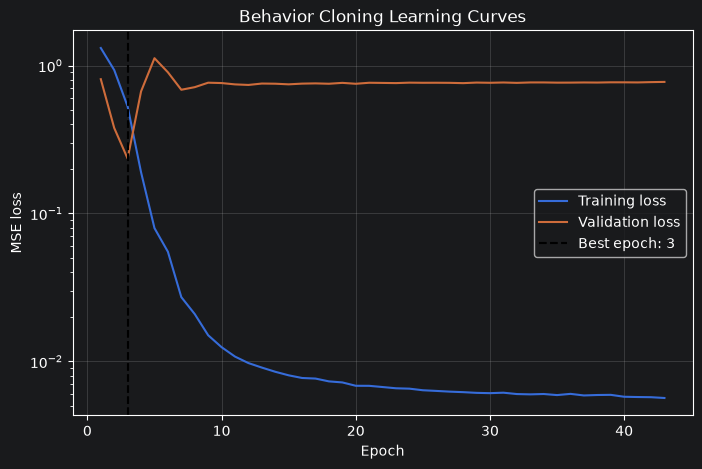

In [18]:
import matplotlib.pyplot as plt


epochs = np.arange(
    1,
    len(train_losses) + 1,
)


plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training loss",
)

plt.plot(
    epochs,
    validation_losses,
    label="Validation loss",
)

plt.axvline(
    best_epoch,
    color="black",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Behavior Cloning Learning Curves")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [19]:
checkpoint_directory = (
    project_root / "checkpoints"
)

checkpoint_directory.mkdir(
    parents=True,
    exist_ok=True,
)


checkpoint_path = (
    checkpoint_directory
    / "pickcube_bc_best.pt"
)


torch.save(
    {
        "model_state_dict": model.state_dict(),

        "observation_mean": torch.from_numpy(
            observation_mean.astype(np.float32)
        ),

        "observation_std": torch.from_numpy(
            observation_std.astype(np.float32)
        ),

        "observation_dim": 42,
        "action_dim": 8,
        "hidden_dim": 64,

        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,

        "training_episodes": training_episodes,
        "validation_episodes": validation_episodes,
    },
    checkpoint_path,
)


print("Saved checkpoint:", checkpoint_path)

Saved checkpoint: /home/bowenyuan/Projects/embodied-ai-learning/checkpoints/pickcube_bc_best.pt


在继续 2.8.8 闭环部署前，我们先回答两个问题：

1. epoch 3 的模型是否比“永远输出训练集平均动作”的简单 baseline 更好？
2. 8 个动作维度中，究竟是哪几个维度泛化最差？

## 1. 恢复最佳模型并与 baseline 比较

In [20]:
assert best_model_state is not None

model.load_state_dict(best_model_state)
model.eval()


validation_predictions = []
validation_targets = []


with torch.no_grad():
    for observations, expert_actions in validation_loader:
        observations = observations.to(device)

        predicted_actions = model(observations)

        validation_predictions.append(
            predicted_actions.cpu()
        )

        validation_targets.append(
            expert_actions.cpu()
        )


validation_predictions = torch.cat(
    validation_predictions,
    dim=0,
).numpy()

validation_targets = torch.cat(
    validation_targets,
    dim=0,
).numpy()


model_validation_mse = np.mean(
    (
        validation_predictions
        - validation_targets
    ) ** 2
)


# A naive baseline that always predicts
# the mean training action
mean_training_action = train_actions.mean(
    axis=0,
    keepdims=True,
)

baseline_predictions = np.repeat(
    mean_training_action,
    repeats=len(validation_actions),
    axis=0,
)

baseline_validation_mse = np.mean(
    (
        baseline_predictions
        - validation_actions
    ) ** 2
)


print("Best BC validation MSE :", model_validation_mse)
print("Mean-action baseline MSE:", baseline_validation_mse)

print(
    "Improvement over baseline:",
    baseline_validation_mse
    - model_validation_mse,
)

Best BC validation MSE : 0.23502295
Mean-action baseline MSE: 0.14210252
Improvement over baseline: -0.09292042


## 2. 检查每个动作维度

RMSE=开根号MSE

In [21]:
action_names = [
    "joint_1",
    "joint_2",
    "joint_3",
    "joint_4",
    "joint_5",
    "joint_6",
    "joint_7",
    "gripper",
]


per_action_mse = np.mean(
    (
        validation_predictions
        - validation_targets
    ) ** 2,
    axis=0,
)

per_action_rmse = np.sqrt(per_action_mse)


print(
    f"{'Action':<12}"
    f"{'MSE':>12}"
    f"{'RMSE':>12}"
    f"{'Target std':>14}"
)

for index, name in enumerate(action_names):
    print(
        f"{name:<12}"
        f"{per_action_mse[index]:>12.6f}"
        f"{per_action_rmse[index]:>12.6f}"
        f"{validation_targets[:, index].std():>14.6f}"
    )

Action               MSE        RMSE    Target std
joint_1         0.012036    0.109708      0.043587
joint_2         0.409044    0.639566      0.241712
joint_3         0.029163    0.170772      0.018589
joint_4         0.570398    0.755247      0.120450
joint_5         0.018995    0.137824      0.002341
joint_6         0.152755    0.390839      0.132008
joint_7         0.126312    0.355404      0.057061
gripper         0.561481    0.749320      0.994444


## 3. 检查 validation observation 是否超出训练范围

当前输入标准化使用训练集均值和标准差。如果 validation episode 与训练轨迹差异较大，标准化后可能出现非常大的数值。

In [22]:
maximum_absolute_z = np.max(
    np.abs(normalized_validation_observations),
    axis=0,
)

largest_dimensions = np.argsort(
    maximum_absolute_z
)[::-1][:10]


print(
    f"{'Dimension':<12}"
    f"{'Max |z|':>12}"
    f"{'Train std':>14}"
)

for index in largest_dimensions:
    print(
        f"{index:<12}"
        f"{maximum_absolute_z[index]:>12.4f}"
        f"{observation_std[0, index]:>14.8f}"
    )

Dimension        Max |z|     Train std
39               13.2084    0.00875096
17               11.6160    0.02687092
16                8.1639    0.03020374
34                5.3329    0.00092416
33                4.2029    0.00100102
31                3.2145    0.07168695
10                3.1860    0.21421318
1                 3.0291    0.17716205
27                2.9106    0.03092669
12                2.8868    0.10678365
